2
branin_currin {'low': np.int64(23), 'medium': np.int64(37), 'high': np.int64(100)}


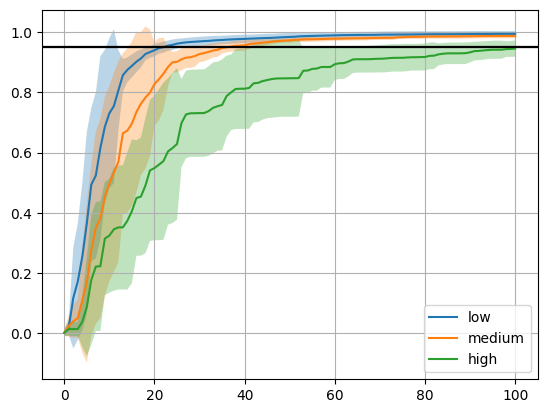

3
Ms_NiTi_Problem {'low': np.int64(76), 'medium': np.int64(100), 'high': np.int64(100)}


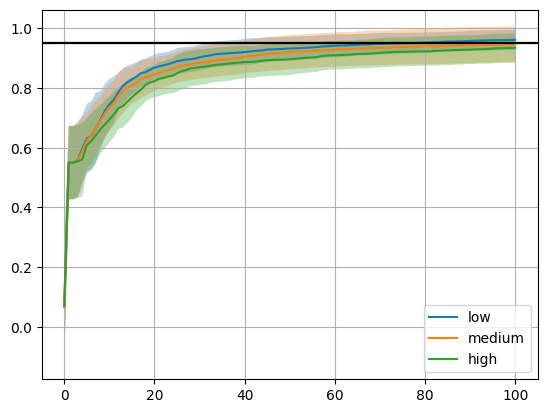

4
NanoParticles {'low': np.int64(5), 'medium': np.int64(6), 'high': np.int64(29)}


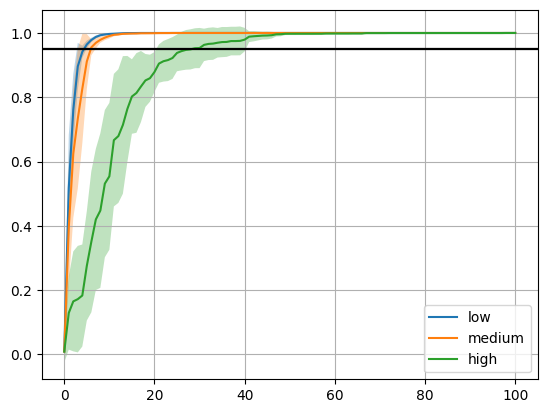

5
EnergyDensity_Problem {'low': np.int64(100), 'medium': np.int64(100), 'high': np.int64(100)}


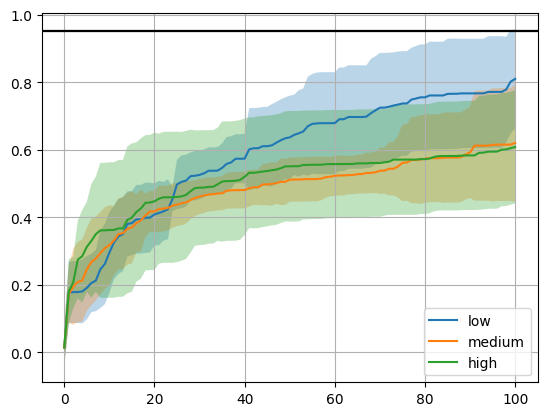

5
PS_ALSC_Problem {'low': np.int64(67), 'medium': np.int64(100), 'high': np.int64(100)}


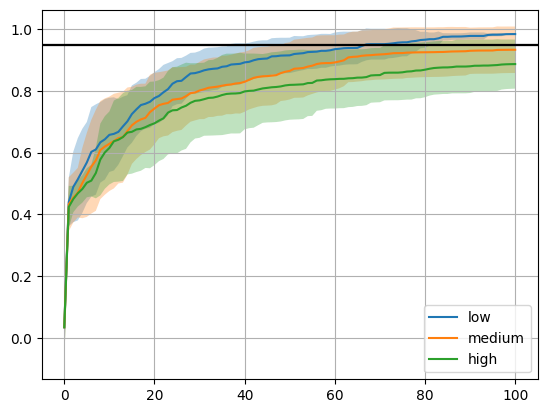

2
Peroskites_Problem {'low': np.int64(10), 'medium': np.int64(19), 'high': np.int64(35)}


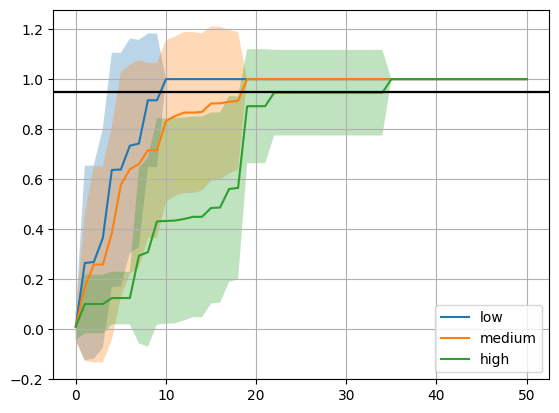

9
Udimet_Problem {'low': np.int64(100), 'medium': np.int64(100), 'high': np.int64(100)}


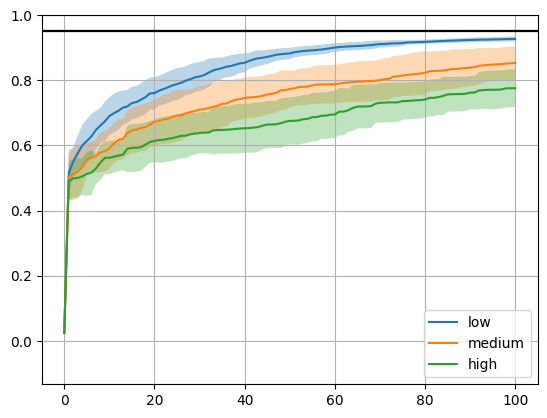

7
Bainite_Problem {'low': np.int64(55), 'medium': np.int64(89), 'high': np.int64(100)}


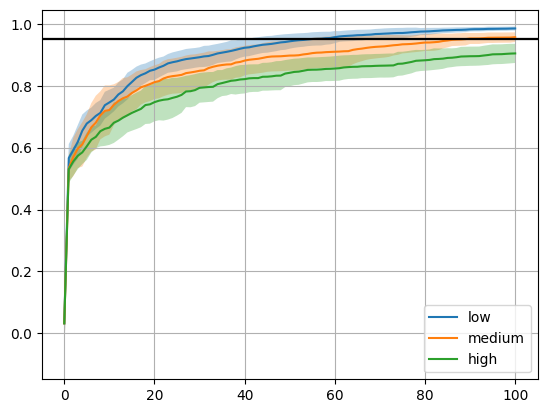

13
Structures_Problem {'low': np.int64(100), 'medium': np.int64(100), 'high': np.int64(100)}


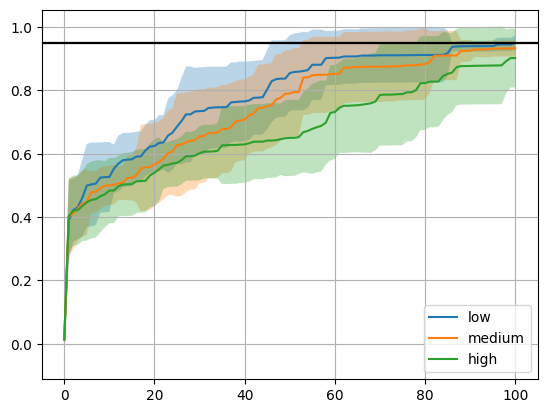

3
Magnetic_Problem {'low': np.int64(37), 'medium': np.int64(38), 'high': np.int64(52)}


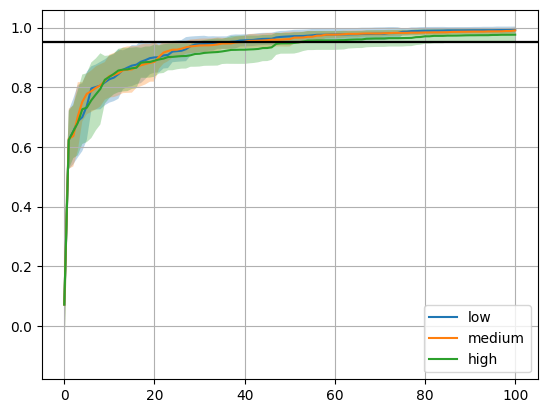

In [4]:
import os
from pathlib import Path
import pibob
from itertools import product
from pibob.problems.registry import PROBLEMS
import pandas as pd
import numpy as np
from pibob.models.analytical_model import PoolDescriptorCore
import torch
from botorch.utils.multi_objective.pareto import is_non_dominated

from botorch.utils.multi_objective.hypervolume import Hypervolume

from pibob.problems.load_points import load_dataset
import matplotlib.pyplot as plt


FM={"Bainite_Problem":[0,9],
    "EnergyDensity_Problem":[0,9],
    "PS_ALSC_Problem":[1,10]}



problems=list(PROBLEMS.keys())
for prob in problems:

    problem = PROBLEMS[prob]()
    path = Path(pibob.PROJECT_ROOT, "results", prob, "datapoints")


    # make configurations
    Knownle = problem.Knowledge

    def sweep_configs():
        knowledge_types = [
            "descriptor",
            "custom_mean",
            "pyro",
            "delta",
            "kernel",
        ] 
        noise_levels = ["low", "medium", "high"]
        places = ["surrogate", "prior", "regularisation"]
        kinds = ["gpr", "identity"] + knowledge_types
        numbers = list(range(0, 10))  # your "number: 1-10"
        aqfs = ["qlognehvi","random"]
        print(problem.dim)

        configurations = {}
        k = 0
        for noise_level, place, kind, number, aqf in product(
            noise_levels, places, kinds, numbers, aqfs
        ):
            j = 1000
            if kind in knowledge_types:
                for j in range(len(Knownle._bank(kind).options)):
                    obj = type(problem.Knowledge._bank(kind).options[j][0])
                    if issubclass(obj, PoolDescriptorCore) and kind=="pyro":
                        continue
                    configurations[k] = {
                        "noise_level": noise_level,
                        "place": place,
                        "kind": kind,
                        "number": number,
                        "knowledge_num": j,
                        "aqf": aqf,
                    }
                    k = k + 1
            else:
                configurations[k] = {
                    "noise_level": noise_level,
                    "place": place,
                    "kind": kind,
                    "number": number,
                    "knowledge_num": j,
                    "aqf": aqf,
                }
                k = k + 1

        return configurations

    configurations=sweep_configs()

    def run_id_from_configuration(configuration) -> str:
        # must match your done_path/claim_path naming exactly
        return "_".join(f"{v}" for k, v in sorted(configuration.items()))

    df = pd.DataFrame({})
    ROOT=Path(pibob.PROJECT_ROOT,"results",prob,"results")


    for key1 in configurations.keys():
        try:
            df1=pd.read_csv(Path(ROOT,f"modelresults_{run_id_from_configuration(configurations[key1])}.csv"))
            for key in configurations[key1].keys():
                df1[key]=configurations[key1][key]

            df=pd.concat([df,df1],ignore_index=True)
        except:
            None


    # load points
    points = load_dataset(
        base_dir=path,
        input_names=problem.input_names,
        objective_names=problem.objective_names,
    )

    # --- adapt this depending on what load_dataset returns ---
    # usually you want the objective matrix Y with shape [n_points, n_objectives]
    # e.g. if points is a dict-like object:
    Y=points.all.Y 

    # If all objectives are to be maximized, leave as is.
    # If some objectives are minimized, flip their sign.
    # Example: first objective maximize, second objective minimize
    # Y[:, 1] = -Y[:, 1]

    # keep only Pareto-optimal points
    pareto_mask = is_non_dominated(Y)
    pareto_Y = Y[pareto_mask]

    # choose a reference point WORSE than all Pareto points
    # Example: slightly below the minimum in each objective
    ref_point = problem.ref_point

    # compute hypervolume
    hv = Hypervolume(ref_point=ref_point)
    hv_value = hv.compute(pareto_Y)


    df_O = pd.DataFrame({})
    ROOT=Path(pibob.PROJECT_ROOT,"results",prob,"results")


    for key1 in configurations.keys():
        try:
            df1=pd.read_csv(Path(ROOT,f"results_{run_id_from_configuration(configurations[key1])}.csv"))
            for key in configurations[key1].keys():
                df1[key]=configurations[key1][key]

            df_O=pd.concat([df_O,df1],ignore_index=True)
        except:
            None

    df_O['hv_q_mean']=df_O['hv_q_mean']/hv_value

    group_cols = [
        "ns_q_mean",
        "noise_level",
        "place",
        "kind",
        "knowledge_num",
        "aqf",
    ]

    df_agg = (
        df_O
        .groupby(group_cols)["hv_q_mean"]
        .agg(["mean", "std","min","max"])
        .reset_index()
    )

    df_selected={}
    for noise in ['low','medium','high']:
        target = (noise, 'surrogate', 'gpr', 1000, 'qlognehvi')

        group_cols = [
            "noise_level",
            "place",
            "kind",
            "knowledge_num",
            "aqf",
        ]

        df_selected[noise] = df_agg[
            df_agg[group_cols].apply(tuple, axis=1) == target
        ]
    plt.figure()
    buget={}
    for noise in ['low','medium','high']:
        plt.plot(df_selected[noise]['ns_q_mean'],df_selected[noise]['mean'],label=noise)
        plt.fill_between(df_selected[noise]['ns_q_mean'],
                        df_selected[noise]['mean']+df_selected[noise]['std'],
                        df_selected[noise]['mean']-df_selected[noise]['std'],alpha=0.3)
        plt.axhline(0.95,color='k')
        nn=np.where(df_selected[noise]['mean']>0.95)
        if len(nn[0]) ==0:
            buget[noise]=df_selected[noise]['ns_q_mean'].to_numpy()[-1]
        else:
            buget[noise]=nn[0][0]
    print(prob, buget)
    plt.grid(True)
    plt.legend()
    plt.show()
    for noise in buget.keys():
        df = df[~((df["noise_level"] == noise) & (df["iter"] != buget[noise]-1))]
    df.reset_index()

    stds=Y.std(dim=0).numpy()
    df["NRMSE"]=df["rmse_obj0"]/stds[0]/2+df["rmse_obj1"]/stds[1]/2
    df["R2"] = 1 - (df["rmse_obj0"]**2 / stds[0]**2*problem.obj_ismodeled[0] + df["rmse_obj1"]**2 / stds[1]**2*problem.obj_ismodeled[1]) / 2



    for noise in buget.keys():
        df_O = df_O[~((df_O["noise_level"] == noise) & (df_O["ns_q_mean"] >= buget[noise]))]
    group_cols = [
        "noise_level",
        "place",
        "kind",
        "knowledge_num",
        "aqf",
        "number"
    ]

    df_agg = (
        df_O
        .groupby(group_cols)["hv_q_mean"]
        .agg(["mean","max"])
        .reset_index()
    )
    df_agg=df_agg.rename(columns={"mean": "sum"})
    # baseline keys vary
    base_keys = ["noise_level", "number"]

    # baseline is defined by this exact setup
    baseline_cfg = (
        (df_agg["place"] == "surrogate") &
        (df_agg["kind"] == "gpr") &
        (df_agg["knowledge_num"] == 1000) &
        (df_agg["aqf"] == "qlognehvi")
    )

    # extract baseline sum for each (noise_level, number)
    ref = (
        df_agg.loc[baseline_cfg, base_keys + ["sum"]]
            .rename(columns={"sum": "sum_baseline"})
    )

    # merge baseline onto all rows by (noise_level, number)
    df_norm = df_agg.merge(ref, on=base_keys, how="left")

    # normalize
    df_norm["sum_normalized"] = df_norm["sum"] - df_norm["sum_baseline"]


    highlight1 = df_norm[
        (df_norm["kind"] == "gpr") &
        (df_norm["knowledge_num"] == 1000) &
        (df_norm["place"] == "surrogate")&
        (df_norm["aqf"] == "qlognehvi")
        ][["noise_level", "max","number"]]

    highlight1 = highlight1.rename(columns={"max": "max_ref"})

    df_norm = df_norm.merge(highlight1, on=["noise_level", "number"], how="left")
    df_norm["max"] = df_norm["max"] - df_norm["max_ref"]


    group_cols_avg = [
        "noise_level",
        "place",
        "kind",
        "knowledge_num",
        "aqf"
    ]
    df_avg = (
        df_norm
        .groupby(group_cols_avg)
            .agg(
            normalized_hvi=("sum_normalized", "mean"),
            normalized_hvi_samples=("sum_normalized", list), 
            normalized_hvi_std=("sum_normalized", "std"),
            max_hvi=("max", "mean"),
            max_hvi_std=("max", "std"),
        ).reset_index()
    )

    metric = "R2"
    base_keys = ["noise_level", "kind", "number", "knowledge_num"]
    if "iter" in df.columns:
        base_keys = base_keys + ["iter"]


    tmp = df[base_keys + ["place", "aqf", metric]].copy()
    tmp = tmp[tmp["aqf"].isin(["random", "qlognehvi"])].copy()
    df_q = tmp[tmp["aqf"] == "qlognehvi"].copy()
    df_q = df_q[base_keys + ["place", metric]].rename(columns={metric: "qlognehvi"})

    df_r = tmp[(tmp["aqf"] == "random") & (tmp["place"] == "surrogate")].copy()
    df_r = df_r[base_keys + [metric]].rename(columns={metric: "random"})

    df_pair = pd.merge(df_q, df_r, on=base_keys, how="inner")

    highlight = df_pair[
        (df_pair["kind"] == "gpr") &
        (df_pair["knowledge_num"] == 1000) &
        (df_pair["place"] == "surrogate")
        ][["noise_level", "qlognehvi","number","random"]]

    highlight = highlight.rename(columns={"qlognehvi": "qlognehvi_ref",
                                          "random": "random_ref"})
    df_pair = df_pair.merge(highlight, on=["noise_level","number"], how="left")

    df_pair["diff"] = df_pair["qlognehvi"] - df_pair["qlognehvi_ref"]
    df_pair["diff_random"] = df_pair["random"] - df_pair["qlognehvi_ref"]
    df_pair = (
        df_pair
        .groupby(["noise_level", "kind", "knowledge_num", "place"])
        .agg(
            qlognehvi=("qlognehvi", "mean"),
            qlognehvi_std=("qlognehvi", "std"),
            qlognehvi_samples=("qlognehvi", list),
            random=("random", "mean"),
            random_std=("random", "std"),
            random_samples=("random", list),   
            diff=("diff", "mean"),
            diff_std=("diff", "std"),
            diff_samples=("diff", list),   
            diff_random=("diff_random", "mean"),
            diff_random_std=("diff_random", "std"),
            diff_random_samples=("diff_random", list),
        )

        .reset_index()
    )


    tmp = df_avg.copy()

    df_q = tmp[tmp["aqf"] == "qlognehvi"].copy()

    df_r = tmp[tmp["aqf"] == "random"].copy()
    df_r = df_r.rename(columns={"normalized_hvi": "normalized_hvi_random",
                                "normalized_hvi_std": "normalized_hvi_random_std",
                                "max_hvi": "max_hvi_random",
                                "max_hvi_std": "max_hvi_random_std"})
    
    df_avg = pd.merge(df_q, df_r, on=["noise_level", "kind", "knowledge_num","place"], how="outer")
    
    df_final=pd.merge(df_pair, df_avg, on=["noise_level", "place", "kind", "knowledge_num"], how="outer")

    if prob in FM.keys():
        for kind in ["custom_mean","pyro","delta","descriptor"]:
            L = (df_final["kind"] == kind) & (
                (df_final["knowledge_num"] <= FM[prob][1]) &(df_final["knowledge_num"] >= FM[prob][0])
            )
            df_final.loc[L, "kind"] = "SM+"+kind
            if True:
                mask = df_final["kind"].isin([kind, "SM+"+kind])
                tmp = df_final.loc[mask].sort_values(["kind", "knowledge_num"]).copy()
                tmp["knowledge_num"] = tmp.groupby(["kind", "noise_level", "place"]).cumcount()
                df_final.loc[tmp.index, "knowledge_num"] = tmp["knowledge_num"]


    path = Path(pibob.PROJECT_ROOT, "results", prob, "result.csv")
    df_final.to_csv(path, index=False)